Adiabatic Elimination

In [1]:
import sympy as sp

In [2]:
hbar = sp.symbols('hbar', positive=True)
omega1, omega2 = sp.symbols('omega_1 omega_2', real=True)
omegaL1, omegaL2 = sp.symbols('omega_L1 omega_L2', real=True)
Omega1, Omega2 = sp.symbols('Omega_1 Omega_2')
t = sp.symbols('t', real=True)

H = hbar * sp.Matrix([
    [-omega1,                    0,                       sp.conjugate(Omega1) * sp.cos(omegaL1 * t)],
    [0,                          -omega2,                 sp.conjugate(Omega2) * sp.cos(omegaL2 * t)],
    [Omega1 * sp.cos(omegaL1 * t), Omega2 * sp.cos(omegaL2 * t), 0],
])

H

Matrix([
[               -hbar*omega_1,                            0, hbar*cos(omega_L1*t)*conjugate(Omega_1)],
[                           0,                -hbar*omega_2, hbar*cos(omega_L2*t)*conjugate(Omega_2)],
[Omega_1*hbar*cos(omega_L1*t), Omega_2*hbar*cos(omega_L2*t),                                       0]])

In [3]:
U = sp.exp(sp.Matrix([[-1j*t*omegaL1, 0,             0],
                      [0,             -1j*t*omegaL2, 0],
                      [0, 0, 0]]))
U

Matrix([
[1.0*exp(-I*omega_L1*t),                      0,   0],
[                     0, 1.0*exp(-I*omega_L2*t),   0],
[                     0,                      0, 1.0]])

In [4]:
H_rot = U.H*H*U - 1j*hbar*U*(U.H).diff(t)
H_rot = sp.simplify(H_rot)
H_rot

Matrix([
[                     1.0*hbar*(-omega_1 + omega_L1),                                                   0, 1.0*hbar*exp(I*omega_L1*t)*cos(omega_L1*t)*conjugate(Omega_1)],
[                                                  0,                      1.0*hbar*(-omega_2 + omega_L2), 1.0*hbar*exp(I*omega_L2*t)*cos(omega_L2*t)*conjugate(Omega_2)],
[1.0*Omega_1*hbar*exp(-I*omega_L1*t)*cos(omega_L1*t), 1.0*Omega_2*hbar*exp(-I*omega_L2*t)*cos(omega_L2*t),                                                             0]])

In [6]:
sp.simplify(H_rot.eigenvals())

{-0.333333333333333*hbar*(omega_1 + omega_2 - omega_L1 - omega_L2) - 0.139991227766097*(-3.0*hbar**2*(-Omega_1*cos(omega_L1*t)**2*conjugate(Omega_1) - Omega_2*cos(omega_L2*t)**2*conjugate(Omega_2) + (omega_1 - omega_L1)*(omega_2 - omega_L2)) + 1.0*hbar**2*(omega_1 + omega_2 - omega_L1 - omega_L2)**2)/(hbar**3*(-Omega_1*(omega_2 - omega_L2)*cos(omega_L1*t)**2*conjugate(Omega_1) - Omega_2*(omega_1 - omega_L1)*cos(omega_L2*t)**2*conjugate(Omega_2)) - 0.333333333333333*hbar**3*(-Omega_1*cos(omega_L1*t)**2*conjugate(Omega_1) - Omega_2*cos(omega_L2*t)**2*conjugate(Omega_2) + (omega_1 - omega_L1)*(omega_2 - omega_L2))*(omega_1 + omega_2 - omega_L1 - omega_L2) + 0.0740740740740741*hbar**3*(omega_1 + omega_2 - omega_L1 - omega_L2)**3 + sqrt(-0.148148148148148*(-hbar**2*(-Omega_1*cos(omega_L1*t)**2*conjugate(Omega_1) - Omega_2*cos(omega_L2*t)**2*conjugate(Omega_2) + (omega_1 - omega_L1)*(omega_2 - omega_L2)) + 0.333333333333333*hbar**2*(omega_1 + omega_2 - omega_L1 - omega_L2)**2)**3 + (hbar**3*

## Testing 
Obtain the 3LS Hamiltonian at each time step.

In [ ]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [8]:
### SET UP FOR A THREE LEVEL SYSTEM
ground = Qobj([[1],[0],[0]])  
storage = Qobj([[0],[1],[0]]) 
excited = Qobj([[0],[0],[1]]) 

sigma_ee = Qobj([[0,0,0],[0,0,0],[0,0,1]])  # |e><e| (excited state population)

sigma_ge = Qobj([[0,0,0],[0,0,0],[1,0,0]])  # |e><g| (transition from g to e)
sigma_eg = Qobj([[0,0,1],[0,0,0],[0,0,0]])  # |g><e| (transition from e to g)

sigma_se = Qobj([[0,0,0],[0,0,0],[0,1,0]])  # |e><s| (transition from s to e)
sigma_es = Qobj([[0,0,0],[0,0,1],[0,0,0]])  # |s><e| (transition from e to s)

sigma_gs = Qobj([[0,0,0],[1,0,0],[0,0,0]])  # |s><g| (transition from g to s)
sigma_sg = Qobj([[0,1,0],[0,0,0],[0,0,0]])  # |g><s| (transition from s to g)

Area of alpha: 0.00999999999999231


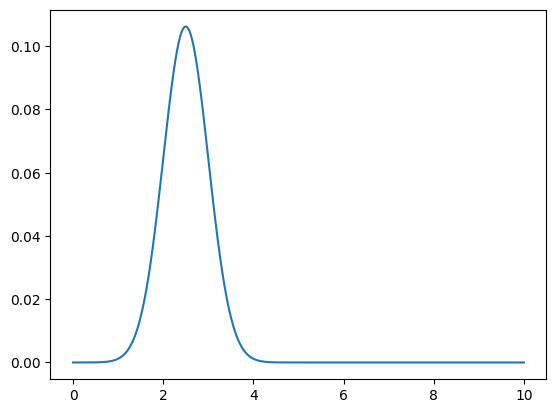

In [9]:
time_final = 10 # total time we will simulate for
N = 5000 # number of time steps

mu, sigma = 2.5, 0.5 # 2.5, 0.5 # defined for a Gaussian input pulse
T = 5 # input pulse "duration" (make sure to adjust this if input pulse changes)

# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    amp = 0.1 # small amplitude
    return amp*(gaussian(mu, sigma, t)) 

time = np.linspace(0, time_final, N)
alpha = alpha_in(time) # input signal

plt.plot(time, alpha)
print("Area of alpha:", integrate.simps(alpha**2, time))

In [10]:
gamma = 1       # decay rate
C = 100           # cooperativity (higher = more efficient)
Delta = 700        # detuning

# Precompute prefactors (constants)
a = -(gamma*(1+C) - 1j*Delta) / np.sqrt(2*gamma*(1+C))
c = gamma**2*(1+C)**2 + Delta**2

# Compute b
b = [0]
for i in range(1, len(time)):
    integral_val = integrate.simps(abs(alpha[0:i])**2, time[0:i]) # integral (0 to t) of |alpha|^2
    if (integral_val == 0):
        b.append(0)
    else:      
        b.append(alpha[i] / (np.sqrt(integral_val)))
b = np.array(b)

In [ ]:
# Returns the integral of |beta(t)|^2 from t[idx] to t[end_of_pulse]
def get_h(beta_vals, idx, time):
    T_index = np.where(time > T)[0][0] # find closest index corresponding to time T
    if idx >= T_index:
        h_val = 0
    else:
        h_val = integrate.simps(np.abs(beta_vals[idx:T_index])**2, time[idx:T_index]) # Integrate beta from time[idx] to time[T_index]
    return h_val

In [16]:
beta_vals = np.array([0])
h_vals = np.array([0])

for idx in tqdm(range(0, len(time)-1)):
    h = get_h(a*b, idx, time)
    if np.imag(h) != 0: print('Imaginary part detected')
    beta_vals = np.append(beta_vals, a*b[idx]*np.exp(1j*Delta*h/c))
    h_vals = np.append(h_vals, h)

def beta(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, beta_vals)  # Interpolate smoothed g values    

100%|██████████| 4999/4999 [00:00<00:00, 7984.41it/s] 


In [13]:
### ---------------------------- HAMILTONIAN ---------------------------------
g_se = 1
g_ge = np.sqrt(2*C*gamma) 

H_signal = sigma_ge
H_signal_dag = sigma_eg
H_coupling = sigma_se
H_coupling_dag = sigma_es
H_detuning = sigma_ee 

def H_detuning_coeff(t, args):
    return Delta

def H_signal_coeff(t, args): 
    return g_ge * alpha_in(t) 

def H_signal_dag_coeff(t, args): 
    return g_ge * np.conjugate(alpha_in(t))

def H_coupling_coeff(t, args):
    return g_se * beta(t)

def H_coupling_dag_coeff(t, args):
    return g_se * np.conjugate(beta(t))

H = [[H_detuning, H_detuning_coeff], [H_signal, H_signal_coeff], [H_signal_dag, H_signal_dag_coeff], 
     [H_coupling, H_coupling_coeff], [H_coupling_dag, H_coupling_dag_coeff]] # Final Hamiltonian 

In [27]:
from qutip import QobjEvo
H_t = QobjEvo(H)
H_at_t = H_t(time[100])         # Qobj — the Hamiltonian evaluated at time t
print(H_at_t)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.00000000e+00  +0.j         0.00000000e+00  +0.j
  3.82002988e-05  +0.j        ]
 [0.00000000e+00  +0.j         0.00000000e+00  +0.j
  1.35749784e+02+176.21685426j]
 [3.82002988e-05  +0.j         1.35749784e+02-176.21685426j
  7.00000000e+02  +0.j        ]]


In [28]:
evals, ekets = H_at_t.eigenstates()        # ekets is an array of Qobj kets

# eigenvalue matrix (diagonal)
E = np.diag(evals)

# eigenvector matrix — columns are eigenvectors
U = np.column_stack([ket.full().ravel() for ket in ekets])

print("Eigenvalues (diagonal matrix E):")
print(E)
print("\nEigenvectors (columns of U):")
print(U)


Eigenvalues (diagonal matrix E):
[[-6.47051766e+01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -1.42108547e-14  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  7.64705177e+02]]

Eigenvectors (columns of U):
[[ 1.64896911e-07+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
  -4.79661674e-08-0.00000000e+00j]
 [ 5.85982852e-01+7.60664598e-01j -1.04802791e-07-1.36044549e-07j
  -1.70454082e-01-2.21266519e-01j]
 [-2.79308908e-01+0.00000000e+00j -6.61744490e-23+0.00000000e+00j
  -9.60201299e-01+0.00000000e+00j]]
